# Linear Regression for Finance
## CAPM Beta Analysis — Apple vs S&P 500

---

### What is CAPM?

The **Capital Asset Pricing Model (CAPM)** describes the relationship between the expected return of a stock and the risk of the overall market.

The core idea: *an investor should be compensated for taking on extra risk*.

---

### The CAPM Regression Equation

We model the relationship as a simple linear regression:

$$R_{stock} = \alpha + \beta \cdot R_{market} + \varepsilon$$

Where:

| Symbol | Name | Meaning |
|--------|------|---------|
| $R_{stock}$ | Stock Return | Daily return of the stock (Apple) |
| $R_{market}$ | Market Return | Daily return of the market (S&P 500) |
| $\alpha$ | Alpha | Return independent of the market (excess return) |
| $\beta$ | Beta | Sensitivity of the stock to market movements |
| $\varepsilon$ | Residual | Unexplained variation (noise) |

---

### What we will do in this notebook

1. Download Apple (`AAPL`) and S&P 500 (`^GSPC`) price data
2. Calculate daily returns
3. Visualize the relationship between them
4. Fit a linear regression model
5. Extract and interpret $\alpha$ and $\beta$
6. Evaluate model fit using $R^2$
7. Analyse residuals

**Central Question:** *How sensitive is Apple to movements in the overall market?*

---
## Step 1 — Install Libraries

Run this cell once if you do not have these packages installed.

In [ ]:
!pip install yfinance scikit-learn

---
## Step 2 — Import Libraries

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

---
## Step 3 — Download Price Data

We download **5 years** of daily closing prices for:
- `AAPL` — Apple Inc.
- `^GSPC` — S&P 500 Index (our proxy for the overall market)

`auto_adjust=True` automatically adjusts prices for stock splits and dividends, giving us clean return data.

In [3]:
stocks = yf.download(
    ["AAPL","^GSPC"],
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=True
)

stocks.head()

[*********************100%***********************]  2 of 2 completed


Price           Close                    High                     Low  \
Ticker           AAPL        ^GSPC       AAPL        ^GSPC       AAPL   
Date                                                                    
2020-01-02  72.333870  3257.850098  72.394078  3258.139893  71.091176   
2020-01-03  71.630630  3234.850098  72.389250  3246.149902  71.406659   
2020-01-06  72.201408  3246.280029  72.239942  3246.840088  70.503546   
2020-01-07  71.861847  3237.179932  72.466330  3244.909912  71.642689   
2020-01-08  73.017853  3253.050049  73.318893  3267.070068  71.565636   

Price                         Open                  Volume              
Ticker            ^GSPC       AAPL        ^GSPC       AAPL       ^GSPC  
Date                                                                    
2020-01-02  3235.530029  71.344047  3244.669922  135480400  3459930000  
2020-01-03  3222.340088  71.563198  3226.360107  146322800  3484700000  
2020-01-06  3214.639893  70.754014  3217.550049  118387200  3702460000  
2020-01-07  3232.429932  72.211049  3241.860107  108872000  3435910000  
2020-01-08  3236.669922  71.565636  3238.590088  132079200  3726840000

---
## Step 4 — Extract Closing Prices

Newer versions of `yfinance` return a **MultiIndex** DataFrame (columns have two levels: field and ticker).
The code below handles both old and new versions safely.

In [4]:
# Handle both old and new yfinance column formats

if isinstance(stocks.columns, pd.MultiIndex):
    close = stocks["Close"]
else:
    close = stocks[["AAPL","^GSPC"]]

close.head()

Ticker,AAPL,^GSPC
Date,,
2020-01-02,72.333870,3257.850098
2020-01-03,71.630630,3234.850098
2020-01-06,72.201408,3246.280029
2020-01-07,71.861847,3237.179932
2020-01-08,73.017853,3253.050049


---
## Step 5 — Plot Prices Over Time

A first look at how Apple and the S&P 500 have moved together over the 5-year period.

> **Note:** The two series have very different absolute price levels, so the chart shows relative direction rather than magnitude.

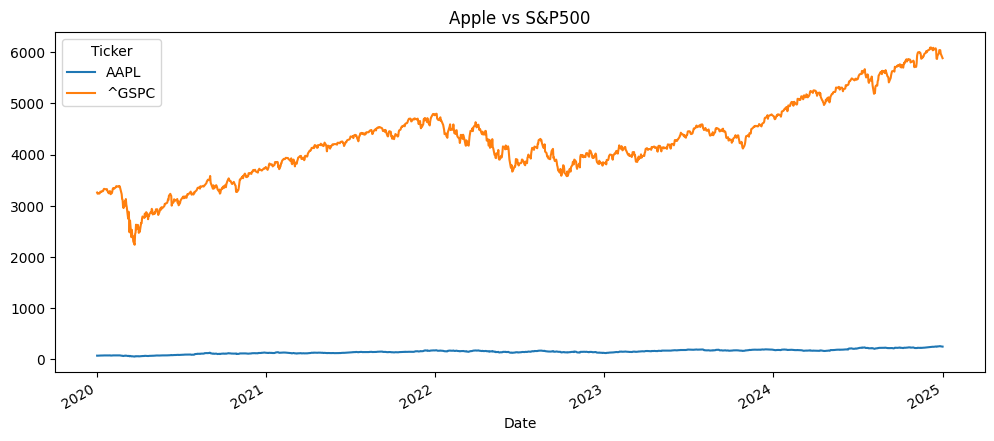

In [5]:
close.plot(
    figsize=(12,5),
    title="Apple vs S&P500"
)

plt.show()

---
## Step 6 — Calculate Daily Returns

We work with **daily percentage returns** rather than raw prices.

$$R_t = \frac{P_t - P_{t-1}}{P_{t-1}}$$

Using returns (instead of prices) makes the two series comparable and is standard practice in quantitative finance. `pct_change()` computes this automatically; `dropna()` removes the first row which has no prior price.

In [6]:
# Compute daily percentage returns and drop the first NaN row
returns = close.pct_change().dropna()

returns.head()

Ticker,AAPL,^GSPC
Date,,
2020-01-03,-0.009722,-0.007060
2020-01-06,0.007968,0.003533
2020-01-07,-0.004703,-0.002803
2020-01-08,0.016087,0.004902
2020-01-09,0.021240,0.006655


In [7]:
# Rename columns for clarity
returns.columns = [
    "Apple_Return",
    "Market_Return"
]

returns.head()

,Apple_Return,Market_Return
Date,,
2020-01-03,-0.009722,-0.007060
2020-01-06,0.007968,0.003533
2020-01-07,-0.004703,-0.002803
2020-01-08,0.016087,0.004902
2020-01-09,0.021240,0.006655


---
## Step 7 — Visualise the Return Distributions

Histograms show us the spread and shape of each return series.

In an efficient market, returns should be approximately **normally distributed** and centred near zero.

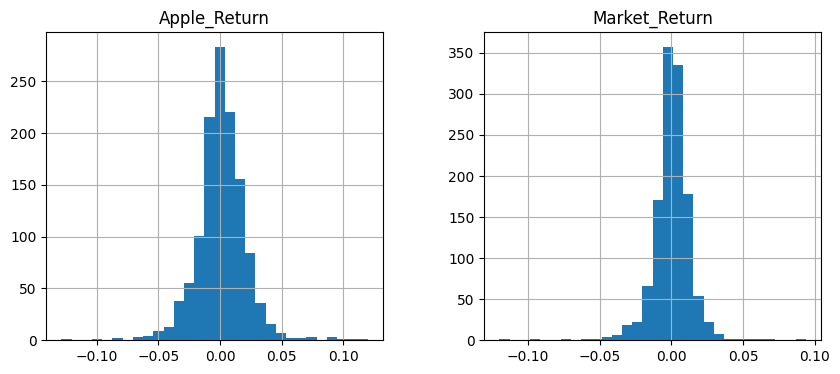

In [8]:
returns.hist(
    figsize=(10,4),
    bins=30
)

plt.show()

---
## Step 8 — Scatter Plot: Apple vs Market

This is the **most important plot**.

Each point represents a single trading day. We plot:
- **X-axis:** S&P 500 return (market)
- **Y-axis:** Apple return (stock)

If the cloud of points has a positive upward slope, Apple tends to move with the market. The steepness of that slope is Beta.

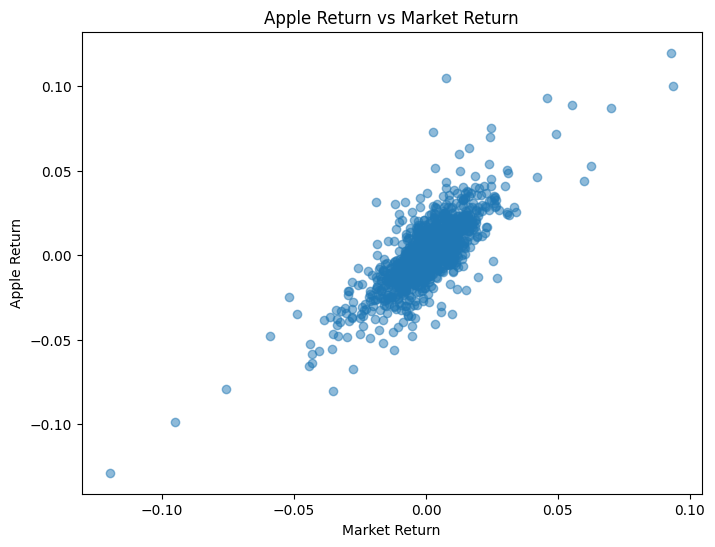

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(
    returns["Market_Return"],
    returns["Apple_Return"],
    alpha=0.5
)

plt.xlabel("Market Return")
plt.ylabel("Apple Return")

plt.title(
    "Apple Return vs Market Return"
)

plt.show()

---
## Step 9 — Correlation

The **Pearson correlation coefficient** $r$ measures the strength and direction of the linear relationship between two variables.

$$r = \frac{\sum (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum(X_i - \bar{X})^2 \cdot \sum(Y_i - \bar{Y})^2}}$$

| Value | Interpretation |
|-------|----------------|
| $r$ close to $+1$ | Strong positive relationship |
| $r$ close to $0$ | Weak or no linear relationship |
| $r$ close to $-1$ | Strong negative relationship |

> **Discussion questions:**
> - Is the correlation positive?
> - Is it strong or weak?
> - Does Apple generally move with the market?

In [10]:
returns.corr()

,Apple_Return,Market_Return
Apple_Return,1.000000,0.790387
Market_Return,0.790387,1.000000


---
## Step 10 — Fit the Linear Regression Model

We now fit the CAPM regression:

$$R_{Apple} = \alpha + \beta \cdot R_{Market}$$

- `X` is the **independent variable** (market return) — must be 2D for scikit-learn, hence `[[...]]`
- `y` is the **dependent variable** (Apple return)

In [11]:
# X must be a 2D array for scikit-learn
X = returns[["Market_Return"]]

y = returns["Apple_Return"]

## We do not split X and y into training + test

### Reason

**1. The goal is estimation, not prediction**
We are not trying to predict future returns. We are measuring a relationship — how sensitive Apple is to the market. That calls for inference, not a predictive model, so there is no "test set" needed.

**2. More data = more accurate Beta**
Splitting throws away valid observations. In regression, every additional data point tightens your coefficient estimates. Deliberately discarding 20% of your data makes your Beta *less* reliable for no benefit.


**3. Time-series data cannot be split randomly anyway**
Even if you wanted a split, randomly shuffling financial data would mix past and future observations into training — that is data leakage. Time-series splits must always be chronological, and for a pure estimation task like CAPM, even that is unnecessary.

In [12]:
# Create and fit the linear regression model
model = LinearRegression()

model.fit(X, y)

LinearRegression()

---
## Step 11 — Extract Alpha and Beta

After fitting:
- `model.intercept_` gives us $\alpha$ — the return when the market return is zero
- `model.coef_[0]` gives us $\beta$ — the slope of the regression line

In [13]:
alpha = model.intercept_

beta = model.coef_[0]

print("Alpha =", alpha)
print("Beta =", beta)

Alpha = 0.0005240354713131545
Beta = 1.1733107533112535


---
## Interpreting Beta

$$\beta = \frac{\text{Cov}(R_{stock},\; R_{market})}{\text{Var}(R_{market})}$$

Beta tells us how much the stock moves **relative to the market**:

| Beta | Interpretation |
|------|----------------|
| $\beta > 1$ | Stock is **more volatile** than the market (amplified swings) |
| $\beta = 1$ | Stock moves **in line** with the market |
| $\beta < 1$ | Stock is **less volatile** than the market (dampened swings) |
| $\beta < 0$ | Stock moves **opposite** to the market (rare) |

### Interpreting Alpha

Alpha represents the **excess return** not explained by the market. In theory, a perfectly efficient market implies $\alpha = 0$. A positive alpha suggests the stock has outperformed the market on a risk-adjusted basis over the period.

---
## Step 12 — Generate Predictions

In [20]:
# Predicted Apple returns based on the fitted model
predictions = model.predict(X)

---
## Step 13 — R² Score (Goodness of Fit)

The **coefficient of determination** $R^2$ tells us what fraction of the variance in Apple's returns is explained by the market:

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

| $R^2$ | Interpretation |
|--------|----------------|
| $R^2 = 1.0$ | Market perfectly explains stock returns |
| $R^2 = 0.5$ | 50% of Apple's movement is explained by the market |
| $R^2 = 0.0$ | Market explains none of the stock's movement |

Note that $R^2 = r^2$ in simple linear regression — it is the square of the correlation coefficient.

In [21]:
r2 = r2_score(y, predictions)

print("R² =", r2)

R² = 0.624711282462046


---
## Step 14 — Plot the Regression Line

We overlay the fitted regression line on the scatter plot. The slope of this line is $\beta$.

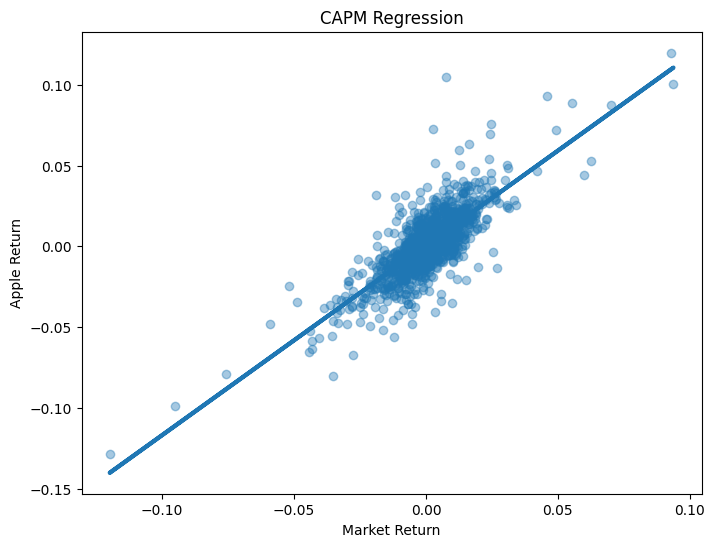

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(
    X,
    y,
    alpha=0.4
)

plt.plot(
    X,
    predictions,
    linewidth=3
)

plt.xlabel("Market Return")
plt.ylabel("Apple Return")

plt.title(
    "CAPM Regression"
)

plt.show()

---
## Step 15 — Residual Analysis

**Residuals** are the differences between actual returns and our model's predictions:

$$\varepsilon_t = R_{Apple,t} - \hat{R}_{Apple,t}$$

They represent the portion of Apple's return that is **not explained by the market** — i.e., company-specific events (earnings surprises, product launches, news).

A well-behaved regression should have residuals that:
- Are centred at zero (no systematic bias)
- Are approximately normally distributed
- Show no obvious pattern

In [23]:
# Residual = actual return minus predicted return
returns["Residual"] = (
    y - predictions
)

returns.head()

,Apple_Return,Market_Return,Residual
Date,,,
2020-01-03,-0.009722,-0.007060,-0.001963
2020-01-06,0.007968,0.003533,0.003299
2020-01-07,-0.004703,-0.002803,-0.001938
2020-01-08,0.016087,0.004902,0.009810
2020-01-09,0.021240,0.006655,0.012908


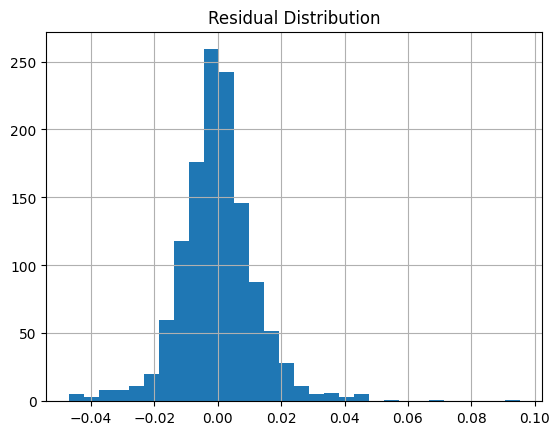

In [24]:
returns["Residual"].hist(
    bins=30
)

plt.title("Residual Distribution")

plt.show()

---
## Step 16 — Final Summary

In [25]:
print("="*40)

print("CAPM RESULTS")

print("="*40)

print(f"Alpha : {alpha:.6f}")

print(f"Beta  : {beta:.4f}")

print(f"R²    : {r2:.4f}")

CAPM RESULTS
Alpha : 0.000524
Beta  : 1.1733
R²    : 0.6247


# Answer

### CAPM Results — Interpretation

---

**Beta = 1.1733**

Apple is slightly more volatile than the market. For every 1% the S&P 500 moves, Apple moves approximately **1.17% in the same direction**. It amplifies market movements, but only modestly — it is not an aggressive high-beta stock like Tesla. Apple behaves like a market-plus stock.

---

**Alpha = 0.000524**

This is the daily return Apple generates **independent of the market**. It looks tiny, but compounded over 252 trading days in a year it adds up to roughly **0.13% extra annual return** above what the market alone would explain. In practice, for CAPM purposes this is considered effectively zero — Apple's returns are almost entirely explained by market movements, with no significant excess return.

---

**R² = 0.6247**

This is arguably the most important number. It means **62.47% of Apple's daily return variation is explained by the S&P 500**. The remaining **37.53% is idiosyncratic** — driven by Apple-specific events like earnings, product launches, supply chain news, and so on. For a single large-cap stock, 62% is actually a strong fit. It confirms Apple is heavily tied to the market but still has meaningful company-specific risk.

---

### One-sentence summary

> Apple is a slightly aggressive market follower — it moves with the market, amplifies it modestly, generates no meaningful excess return on its own, and about 62% of its daily price behaviour is simply the market moving.

---
## Discussion Questions

Answer the following based on the results above:

1. **Is Apple more risky than the market?**  
   *(Hint: Is $\beta > 1$ or $\beta < 1$?)*


> Beta = 1.0 means a stock moves exactly with the market. Apple's Beta of 1.1733 means it is more volatile than the market, but only by about 17%. That is not a dramatic difference. If the S&P 500 drops 10% in a crash, you would expect Apple to drop roughly 11.7%.


   

2. **What does Alpha represent here?**  
   *(Is it positive or negative? Is it large enough to be meaningful?)*

> (Answer given above)

3. **Is Apple strongly related to market movements?**  
   *(Look at $R^2$. What percentage of Apple's variation is explained by the market?)*

> (Answer given above)

4. **What would happen if we used Tesla (`TSLA`) instead of Apple?**  
   *(Would you expect a higher or lower Beta? Why?)*

8. **Which stock do you think has the highest Beta?**  
   Try replacing `AAPL` in the download cell with each ticker and compare:
   - Apple — `AAPL`
   - Microsoft — `MSFT`
   - Tesla — `TSLA`

---
## Summary of Learning Outcomes


### Finance Concepts
- **CAPM** — the foundational model linking risk and expected return
- **Alpha** — stock-specific excess return
- **Beta** — systematic market risk
- **Market Risk** — the portion of risk that cannot be diversified away
- **Stock Returns** — measuring performance as percentage change in price

### Python & Data Skills
- `yfinance` — downloading financial data
- `pandas` — data manipulation and feature engineering
- `pct_change()` — computing returns from prices
- Correlation matrices

### Machine Learning
- Simple **Linear Regression** with scikit-learn
- **Prediction** from a fitted model
- **$R^2$ Score** — evaluating goodness of fit
- **Residual Analysis** — checking model assumptions

---